In [1]:
# Import necessary libraries for data manipulation, machine learning, and visualization
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Set plotting style
sns.set_theme(style="whitegrid")


In [3]:
# 1. Load the dataset

path = r'/Users/tyrasmussen/Desktop/FVTC/Spring 2026/Data Analytics Capstone/MM/MM Data/FINAL'

df = pd.read_csv(os.path.join(path, 'FINAL_Valid_MMData_v2.csv'))


/var/folders/l9/n_0jq3zj66l9v7k98dd7cpqc0000gn/T/ipykernel_65168/3348456279.py:5: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'FINAL_Valid_MMData_v2.csv'))


In [4]:
df.head()

,Unnamed: 0,season,team_name,efgpct_off,topct_off,orpct_off,ftrate_off,efgpct_def,topct_def,orpct_def,...,def3ptfg,tempo,adjtempo,adjem,post-season_tournament,tournament_winner,tournament_championship?,final_four?,top_12_in_ap_top_25_during_week_6?,seed
0,0,2019,Abilene Christian,51.933535,17.308266,27.005076,34.018127,49.837557,23.276634,28.481013,...,26.007139,66.4788,66.1485,1.34653,March Madness,0,0,0,0,15.0
1,1,2019,Air Force,51.282799,19.295638,23.166023,28.279883,53.549120,17.785955,24.137931,...,39.300135,67.2794,66.5555,-7.06173,NaN,0,0,0,0,NaN
2,2,2019,Akron,48.191781,17.274562,25.065048,27.671233,45.452024,19.058349,29.873418,...,30.419580,68.4518,66.1796,5.86570,NaN,0,0,0,0,NaN
3,3,2019,Alabama,50.282776,19.523870,31.501231,37.994859,48.925256,16.878700,27.977618,...,27.496917,69.8011,68.7097,10.67790,NIT,0,0,0,0,NaN
4,4,2019,Alabama A&M,45.715865,22.504932,27.821522,25.041459,53.670520,20.949713,31.866029,...,30.853392,67.5600,65.6571,-22.16920,NaN,0,0,0,0,NaN


In [5]:
# 2. Define the target variable
target = 'tournament_winner'

In [6]:
# 3. Drop variables that cause data leakage or are non-predictive strings
# We must drop other post-season outcome variables so the model doesn't cheat [1].
# Updated list of columns to drop
leakage_cols = [
    'Unnamed: 0',
    'post-season_tournament', 
    'tournament_championship?', 
    'final_four?', 
    'team_name', 
    'conference'
]


df_model = df.drop(columns=leakage_cols, errors='ignore')

In [7]:
# Separate features (X) and target (y)
X = df_model.drop(columns=[target])
y = df_model[target]


In [8]:
# 4. Handle missing values
# Some columns like 'seed' or 'top_12_in_ap_top_25_during_week_6?' might have NaNs for unseeded/unranked teams [1].
# We will impute missing numeric values with 0 for this baseline model
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [9]:
# 5. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)


In [10]:
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (6858, 69)
Testing data shape: (1715, 69)


In [11]:
# Initialize the Random Forest Classifier
# Random forests are robust tree-based models that handle complex interactions between variables
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, class_weight='balanced')


In [12]:
# Fit the model to the training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=500,
                       random_state=42)

In [13]:
# Predict on the test set to ensure the model is functioning properly
y_pred = rf_model.predict(X_test)

In [14]:
# Output basic performance metrics
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 0.9965014577259476

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       0.00      0.00      0.00         4

    accuracy                           1.00      1715
   macro avg       0.50      0.50      0.50      1715
weighted avg       1.00      1.00      1.00      1715



In [15]:
# Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_


In [16]:
# Create a DataFrame to hold the feature names and their corresponding importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

In [17]:
# Sort the DataFrame by importance in descending order to see the biggest impacts first
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)


In [18]:
# Display the top 15 most impactful variables
print("Top 15 Variables Impacting Tournament Winner:\n")
print(feature_importance_df.head(15))


Top 15 Variables Impacting Tournament Winner:

                               Feature  Importance
0   top_12_in_ap_top_25_during_week_6?    0.194293
1                                 seed    0.138828
2                                adjem    0.096584
3        adjusted_defensive_efficiency    0.067218
4        adjusted_offensive_efficiency    0.065377
5             raw_offensive_efficiency    0.046548
6             raw_defensive_efficiency    0.032093
7                           ftrate_def    0.030782
8                           efgpct_off    0.028305
9                           efgpct_def    0.023428
10                           oppfg3pct    0.021626
11                            blockpct    0.021596
12                              fg2pct    0.020619
13                              fg3pct    0.020003
14                              season    0.016293


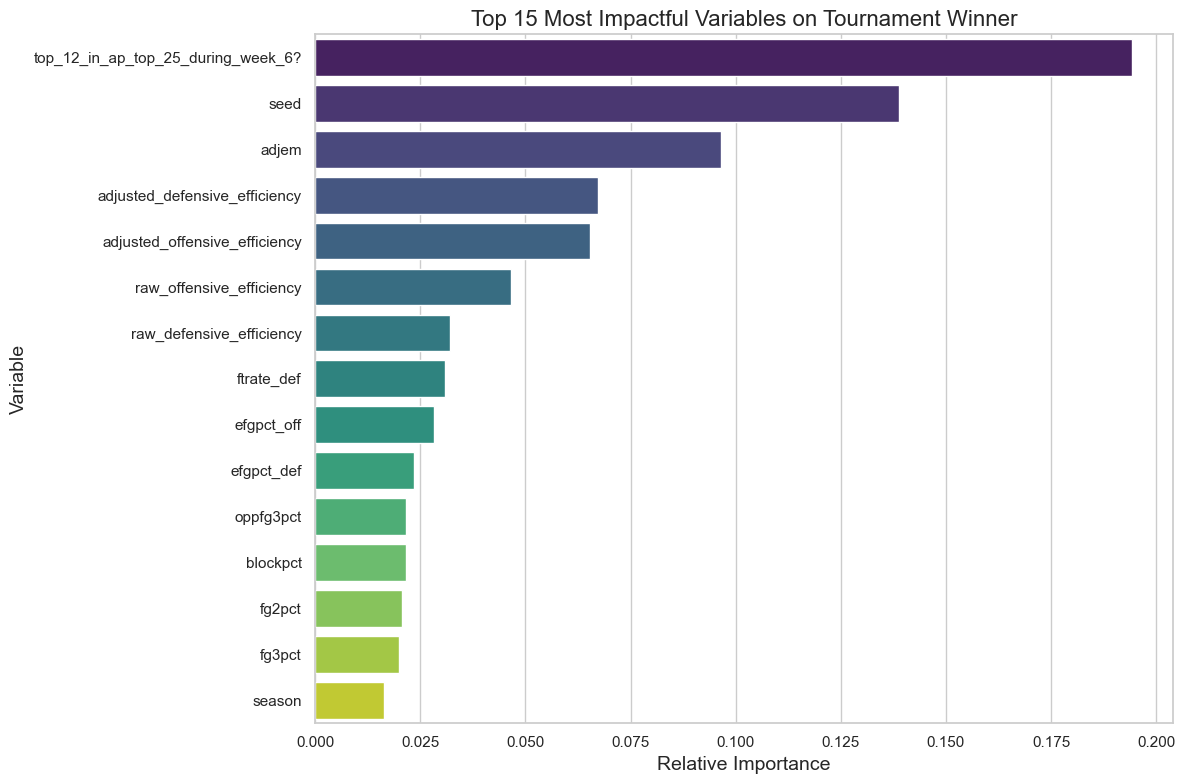

In [19]:
# Visualize the Top 15 Features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Most Impactful Variables on Tournament Winner', fontsize=16)
plt.xlabel('Relative Importance', fontsize=14)
plt.ylabel('Variable', fontsize=14)
plt.tight_layout()
plt.show()


In [20]:
# Save figure
plt.savefig("feature_importance.png")

<Figure size 640x480 with 0 Axes>

In [21]:
feature_importance_df.head()

,Feature,Importance
0,top_12_in_ap_top_25_during_week_6?,0.194293
1,seed,0.138828
2,adjem,0.096584
3,adjusted_defensive_efficiency,0.067218
4,adjusted_offensive_efficiency,0.065377


In [23]:
# Save feature importance to final data folder
feature_importance_df.to_excel(os.path.join(path, 'feature_importance.xlsx'))